# Lesson 5C: Consumption-Based and Production-Based Asset Pricing


Probability, Statistics and Econometrics for Finance, Accounting and Economics  
Campbell University, Lundy-Fetterman School of Business  

**Instructor:** Matthew L. Kelly, PhD


This notebook is the third of three expanded finance lectures. It covers consumption-based asset pricing, the Lucas tree model, the stochastic discount factor, the Hansen-Jagannathan bound, the equity premium puzzle, the risk-free rate puzzle, and a simple production-based asset pricing framework.

It also includes several price-theory diagrams:

1. supply and demand,
2. indifference curves and budget constraints,
3. production functions,
4. isoquant and isocost curves,
5. marginal cost, average total cost, average variable cost, and marginal revenue diagrams.

## Learning objectives

By the end of this lecture, you should be able to:

1. Define the stochastic discount factor.
2. Derive the basic consumption-based asset pricing equation.
3. Explain the Lucas tree model.
4. Explain the equity premium puzzle and risk-free rate puzzle.
5. Interpret the Hansen-Jagannathan bound.
6. Link production, costs, profits, and asset prices.
7. Explain how supply and demand shocks alter firm profits.
8. Explain why firms whose profits covary positively or negatively with the SDF should have different expected returns.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:,.4f}".format

## 1. The central asset pricing equation

Asset pricing begins with the idea that investors trade off consumption today against consumption tomorrow. Let $M_{t+1}$ denote the stochastic discount factor. Then the price of any asset with payoff $X_{t+1}$ is

$$
P_t = \mathbb{E}_t[M_{t+1}X_{t+1}].
$$

The gross return is

$$
R_{t+1} = \frac{X_{t+1}}{P_t}.
$$

Therefore,

$$
1 = \mathbb{E}_t[M_{t+1}R_{t+1}].
$$

This equation is the core of modern asset pricing.

For a risk-free asset with known gross return $R_{f,t+1}$,

$$
1 = R_{f,t+1}\mathbb{E}_t[M_{t+1}],
$$

so

$$
R_{f,t+1} = \frac{1}{\mathbb{E}_t[M_{t+1}]}.
$$

## 2. Consumption, utility, and the SDF

Suppose a representative household has expected utility

$$
\mathbb{E}_0\sum_{t=0}^{\infty}\beta^t u(C_t),
$$

where $0<\beta<1$ is the subjective discount factor.

For CRRA utility,

$$
u(C) = \frac{C^{1-\gamma}}{1-\gamma},
\quad \gamma \ne 1,
$$

and

$$
u'(C)=C^{-\gamma}.
$$

The stochastic discount factor is

$$
M_{t+1}
=
\beta\frac{u'(C_{t+1})}{u'(C_t)}
=
\beta\left(\frac{C_{t+1}}{C_t}\right)^{-\gamma}.
$$

When consumption growth is low, marginal utility tomorrow is high, so $M_{t+1}$ is high. Assets that pay off in those bad states are valuable and should have low expected returns. Assets that pay off mainly in good states are less valuable as insurance and must offer higher expected returns.

## 3. Price theory diagram: indifference curves, budget constraints, and tangency

The household chooses consumption today, $C_t$, and consumption tomorrow, $C_{t+1}$. A two-period budget constraint can be written as

$$
C_{t+1}=(1+r)(W_t-C_t)+Y_{t+1},
$$

or equivalently,

$$
C_{t+1}=(1+r)W_t+Y_{t+1}-(1+r)C_t.
$$

The slope of the budget constraint is

$$
-(1+r).
$$

The optimum occurs where the highest attainable indifference curve is tangent to the budget constraint. For utility

$$
U(C_t,C_{t+1})=u(C_t)+\beta u(C_{t+1}),
$$

the first-order condition is

$$
u'(C_t)=\beta(1+r)u'(C_{t+1}).
$$

Equivalently,

$$
\frac{u'(C_t)}{\beta u'(C_{t+1})}=1+r.
$$

The left side is the marginal rate of substitution between present and future consumption. The right side is the relative price: one extra unit of consumption today costs $1+r$ units of consumption tomorrow. Thus, the tangency condition says:

$$
\text{marginal rate of substitution}=\text{relative price}.
$$

For CRRA utility, $u'(C)=C^{-\gamma}$, so the tangency condition becomes

$$
\left(\frac{C_{t+1}}{C_t}\right)^\gamma=\beta(1+r).
$$

This same marginal-utility logic becomes the stochastic discount factor when tomorrow's consumption is uncertain.

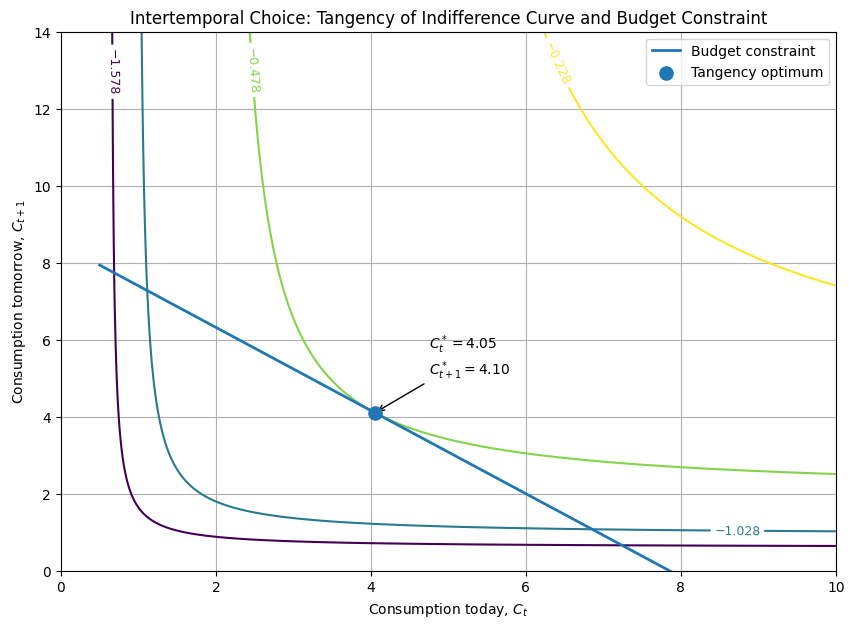

Tangency condition: MU_t / (beta * MU_t+1) = 1.080 = 1 + r
Optimal consumption ratio C_t+1 / C_t = 1.013


In [2]:
# Indifference curves, budget constraint, and tangency solution

gamma = 2.0
beta = 0.95
W0 = 6.0
Y1 = 2.0
r = 0.08
B = (1 + r) * W0 + Y1


def utility(c0, c1, beta=0.95, gamma=2.0):
    c0 = np.asarray(c0)
    c1 = np.asarray(c1)
    if gamma == 1:
        return np.log(c0) + beta * np.log(c1)
    return c0 ** (1 - gamma) / (1 - gamma) + beta * c1 ** (1 - gamma) / (1 - gamma)

# CRRA tangency: (C1/C0)^gamma = beta(1+r)
consumption_ratio = (beta * (1 + r)) ** (1 / gamma)
c0_star = B / ((1 + r) + consumption_ratio)
c1_star = consumption_ratio * c0_star
U_star = utility(c0_star, c1_star, beta=beta, gamma=gamma)

c0_grid = np.linspace(0.5, 10, 300)
c1_grid = np.linspace(0.5, 14, 300)
C0, C1 = np.meshgrid(c0_grid, c1_grid)
U = utility(C0, C1, beta=beta, gamma=gamma)
budget_c1 = B - (1 + r) * c0_grid

plt.figure(figsize=(10, 7))
levels = [U_star - 1.1, U_star - 0.55, U_star, U_star + 0.25]
contours = plt.contour(C0, C1, U, levels=levels)
plt.clabel(contours, inline=True, fontsize=9)
plt.plot(c0_grid, budget_c1, label="Budget constraint", linewidth=2)
plt.scatter(c0_star, c1_star, s=90, zorder=5, label="Tangency optimum")
plt.annotate(
    f"$C_t^*={c0_star:.2f}$\n$C_{{t+1}}^*={c1_star:.2f}$",
    xy=(c0_star, c1_star),
    xytext=(c0_star + 0.7, c1_star + 1.0),
    arrowprops=dict(arrowstyle="->"),
)
plt.xlim(0, 10)
plt.ylim(0, 14)
plt.xlabel("Consumption today, $C_t$")
plt.ylabel("Consumption tomorrow, $C_{t+1}$")
plt.title("Intertemporal Choice: Tangency of Indifference Curve and Budget Constraint")
plt.legend()
plt.show()

print(f"Tangency condition: MU_t / (beta * MU_t+1) = {1+r:.3f} = 1 + r")
print(f"Optimal consumption ratio C_t+1 / C_t = {c1_star / c0_star:.3f}")

## 4. The Lucas tree model

In the Lucas tree model, the economy has a tree that produces a stochastic dividend. The dividend is the consumption good. If the tree pays dividend $D_{t+1}$ and has price $P_{t+1}$ next period, its price today is

$$
P_t
=
\mathbb{E}_t\left[
M_{t+1}(P_{t+1}+D_{t+1})
\right].
$$

The gross equity return is

$$
R^e_{t+1}
=
\frac{P_{t+1}+D_{t+1}}{P_t}.
$$

The pricing equation is

$$
1
=
\mathbb{E}_t[M_{t+1}R^e_{t+1}].
$$

If dividends are consumption, then bad dividend states are also bad consumption states. This is what makes equity risky in the model.

In [3]:
# Consumption-based asset pricing simulation

def simulate_sdf(beta=0.99, gamma=4, mu_g=0.018, sigma_g=0.035, n=50000):
    log_g = np.random.normal(mu_g, sigma_g, n)
    g = np.exp(log_g)
    m = beta * g**(-gamma)
    return g, m

beta = 0.99
gamma = 4
g, m = simulate_sdf(beta=beta, gamma=gamma)

gross_rf = 1 / np.mean(m)
rf = gross_rf - 1

print(f"Mean consumption growth: {np.mean(g)-1:.2%}")
print(f"Mean SDF: {np.mean(m):.4f}")
print(f"Risk-free rate: {rf:.2%}")
print(f"Std. dev. of SDF: {np.std(m):.4f}")

Mean consumption growth: 1.88%
Mean SDF: 0.9304
Risk-free rate: 7.49%
Std. dev. of SDF: 0.1310


## 5. Risk premia and covariance with the SDF

Starting from

$$
1=\mathbb{E}[MR_i],
$$

we can write

$$
1 = \mathbb{E}[M]\mathbb{E}[R_i] + \operatorname{Cov}(M,R_i).
$$

Since

$$
R_f = \frac{1}{\mathbb{E}[M]},
$$

we obtain

$$
\mathbb{E}[R_i] - R_f
=
-R_f \operatorname{Cov}(M,R_i).
$$

This is the key covariance formula.

If an asset pays high returns when $M$ is high, then it pays off in bad times. Its covariance with the SDF is positive, so its expected return is low.

If an asset pays high returns when $M$ is low, then it pays off in good times. Its covariance with the SDF is negative, so its expected return is high.

In [4]:
# Construct two assets: a defensive asset and a cyclical asset

np.random.seed(100)
n = 50000
g, m = simulate_sdf(beta=0.99, gamma=6, mu_g=0.018, sigma_g=0.035, n=n)
growth_shock = g - np.mean(g)

# Defensive payoff is higher when consumption growth is low
defensive_payoff = 1.04 - 1.5 * growth_shock + np.random.normal(0, 0.02, n)

# Cyclical payoff is higher when consumption growth is high
cyclical_payoff = 1.04 + 3.0 * growth_shock + np.random.normal(0, 0.04, n)

price_defensive = np.mean(m * defensive_payoff)
price_cyclical = np.mean(m * cyclical_payoff)

ret_defensive = defensive_payoff / price_defensive
ret_cyclical = cyclical_payoff / price_cyclical
rf = 1 / np.mean(m)

table = pd.DataFrame({
    "Asset": ["Defensive", "Cyclical"],
    "Price": [price_defensive, price_cyclical],
    "Expected Gross Return": [np.mean(ret_defensive), np.mean(ret_cyclical)],
    "Expected Net Return": [np.mean(ret_defensive)-1, np.mean(ret_cyclical)-1],
    "Covariance with SDF": [np.cov(m, ret_defensive)[0,1], np.cov(m, ret_cyclical)[0,1]],
})
table

,Asset,Price,Expected Gross Return,Expected Net Return,Covariance with SDF
0,Defensive,0.9547,1.0894,0.0894,0.0107
1,Cyclical,0.9241,1.1254,0.1254,-0.0220


## 6. The Hansen-Jagannathan bound

The Hansen-Jagannathan bound says that the volatility of the SDF must be large enough to price the observed Sharpe ratios of assets.

For any excess return $R_i^e=R_i-R_f$,

$$
\mathbb{E}[R_i^e]
=
- R_f\operatorname{Cov}(M,R_i^e).
$$

Using the Cauchy-Schwarz inequality,

$$
|\mathbb{E}[R_i^e]|
\le
R_f\sigma_M\sigma_i.
$$

Therefore,

$$
\sigma_M
\ge
\frac{|\mathbb{E}[R_i]-R_f|}{R_f\sigma_i}.
$$

Equivalently, for a given SDF volatility, the largest absolute Sharpe ratio that can be priced is

$$
\left|\frac{\mathbb{E}[R_i]-R_f}{\sigma_i}\right|
\le R_f\sigma_M.
$$

In mean-standard-deviation space, the boundary can be drawn as the return-risk locus implied by a maximum admissible Sharpe ratio. In mean-variance space this locus is literally parabolic; when the vertical axis is standard deviation, it appears as the square root of that parabola:

$$
\sigma_R
=
\sqrt{\sigma_{\min}^2+
\frac{(\mathbb{E}[R]-R_f)^2}{(R_f\sigma_M)^2}}.
$$

The dots below show simple CRRA SDF candidates. Higher $\gamma$ makes marginal utility more volatile, raising $\sigma_M$ and allowing the model to price a larger Sharpe ratio.

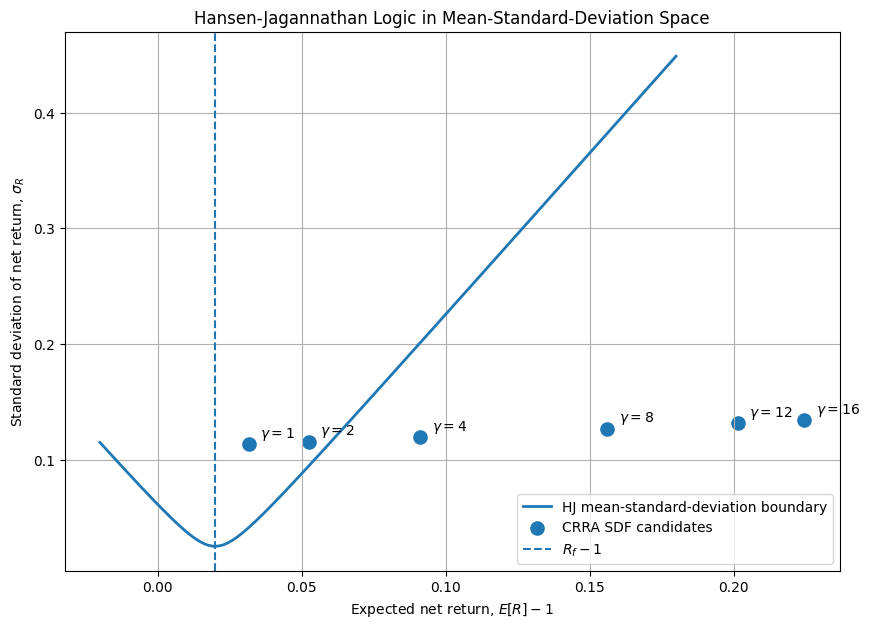

,gamma,mean_return,std_return,std_sdf,sharpe
0,1,0.0317,0.1131,0.0340,0.1033
1,2,0.0524,0.1153,0.0670,0.2812
2,4,0.0912,0.1196,0.1306,0.5955
3,8,0.1562,0.1267,0.2536,1.0747
4,12,0.2015,0.1317,0.3803,1.3782
5,16,0.2246,0.1342,0.5223,1.5246


In [5]:
# HJ bound in mean-standard-deviation space, with CRRA SDF candidates

np.random.seed(123)
rf_net = 0.02
gross_rf = 1 + rf_net
sigma_min = 0.025
candidate_sigma_m = 0.35

mean_returns = np.linspace(-0.02, 0.18, 300)
hj_boundary_sd = np.sqrt(
    sigma_min**2 + ((mean_returns - rf_net) ** 2) / ((gross_rf * candidate_sigma_m) ** 2)
)

# A simple market payoff that is procyclical with consumption growth
n = 60_000
log_g = np.random.normal(0.018, 0.035, n)
growth = np.exp(log_g)
growth_shock = growth - growth.mean()
market_payoff = 1.04 + 3.0 * growth_shock + np.random.normal(0, 0.04, n)

gamma_values = [1, 2, 4, 8, 12, 16]
points = []
for gamma_value in gamma_values:
    sdf = 0.99 * growth ** (-gamma_value)
    price = np.mean(sdf * market_payoff)
    market_return = market_payoff / price - 1
    points.append({
        "gamma": gamma_value,
        "mean_return": np.mean(market_return),
        "std_return": np.std(market_return),
        "std_sdf": np.std(sdf),
        "sharpe": (np.mean(market_return) - rf_net) / np.std(market_return),
    })

hj_points = pd.DataFrame(points)

plt.figure(figsize=(10, 7))
plt.plot(mean_returns, hj_boundary_sd, linewidth=2, label="HJ mean-standard-deviation boundary")
plt.scatter(hj_points["mean_return"], hj_points["std_return"], s=90, label="CRRA SDF candidates")
for _, row in hj_points.iterrows():
    plt.annotate(
        f"$\\gamma={int(row['gamma'])}$",
        xy=(row["mean_return"], row["std_return"]),
        xytext=(row["mean_return"] + 0.004, row["std_return"] + 0.006),
    )
plt.axvline(rf_net, linestyle="--", label="$R_f-1$")
plt.xlabel("Expected net return, $E[R]-1$")
plt.ylabel("Standard deviation of net return, $\\sigma_R$")
plt.title("Hansen-Jagannathan Logic in Mean-Standard-Deviation Space")
plt.legend()
plt.show()

hj_points

## 7. The equity premium puzzle

The equity premium puzzle is the observation that historical equity returns have exceeded safe returns by much more than the simplest consumption-based model predicts using moderate risk aversion.

In the model,

$$
M_{t+1}
=
\beta G_{t+1}^{-\gamma},
$$

where

$$
G_{t+1}=\frac{C_{t+1}}{C_t}.
$$

If consumption growth is smooth, then $M_{t+1}$ is not volatile unless $\gamma$ is very large. But high equity premia require volatile marginal utility or strong negative covariance between equity returns and marginal utility.

The puzzle is therefore:

> Consumption growth is too smooth to generate the observed equity premium unless risk aversion is implausibly high or the model is enriched.

## 8. The risk-free rate puzzle

The risk-free rate is

$$
R_f = \frac{1}{\mathbb{E}[M]}.
$$

With CRRA utility and lognormal consumption growth, a useful approximation is

$$
r_f
\approx
-\log\beta
+
\gamma \mu_g
-
\frac{1}{2}\gamma^2\sigma_g^2.
$$

For plausible consumption growth and risk aversion, the model can imply a risk-free rate that is too high compared with observed safe rates. This is the risk-free rate puzzle.

The equity premium puzzle and risk-free rate puzzle are related. Raising risk aversion can help produce a larger equity premium, but it may create counterfactual implications for the risk-free rate unless other mechanisms are added.

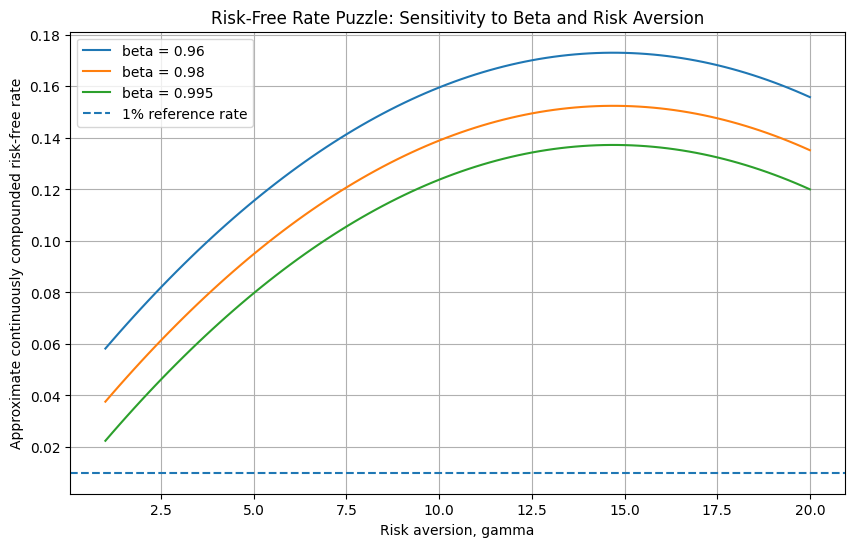

In [6]:
# Risk-free rate sensitivity to beta and gamma

mu_g = 0.018
sigma_g = 0.035
gammas = np.linspace(1, 20, 100)

plt.figure()
for beta_value in [0.96, 0.98, 0.995]:
    approx_rf = -np.log(beta_value) + gammas * mu_g - 0.5 * (gammas**2) * sigma_g**2
    plt.plot(gammas, approx_rf, label=f"beta = {beta_value}")
plt.axhline(0.01, linestyle="--", label="1% reference rate")
plt.xlabel("Risk aversion, gamma")
plt.ylabel("Approximate continuously compounded risk-free rate")
plt.title("Risk-Free Rate Puzzle: Sensitivity to Beta and Risk Aversion")
plt.legend()
plt.show()

## 9. Price theory diagram: supply and demand

Before moving to production-based asset pricing, it is useful to recall the basic supply and demand diagram. A demand shock changes the price the firm receives for output. A supply or cost shock changes the marginal cost of production.

Both types of shocks alter profits, and profits are the cash flows that asset owners ultimately value.

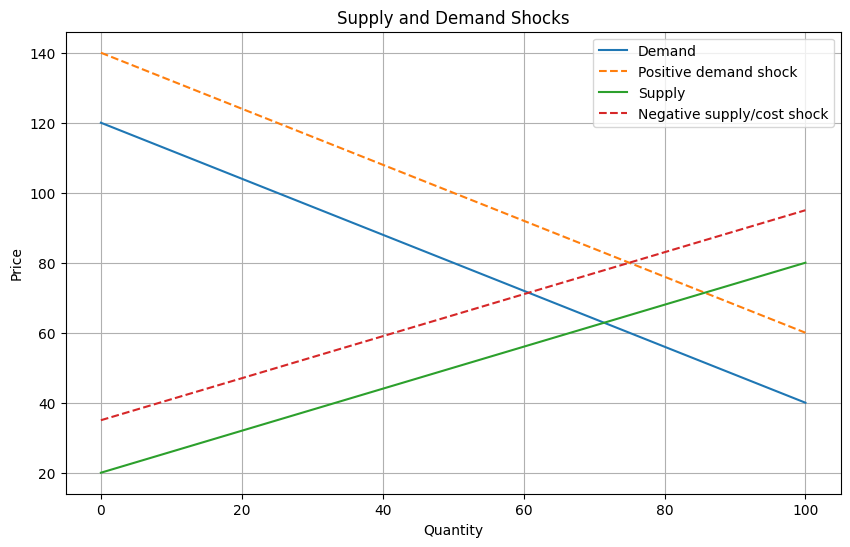

In [7]:
# Supply and demand diagram

Q = np.linspace(0, 100, 200)
demand = 120 - 0.8 * Q
demand_high = 140 - 0.8 * Q
supply = 20 + 0.6 * Q
supply_high_cost = 35 + 0.6 * Q

plt.figure()
plt.plot(Q, demand, label="Demand")
plt.plot(Q, demand_high, linestyle="--", label="Positive demand shock")
plt.plot(Q, supply, label="Supply")
plt.plot(Q, supply_high_cost, linestyle="--", label="Negative supply/cost shock")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Supply and Demand Shocks")
plt.legend()
plt.show()

## 10. Production technology

Consider a firm with Cobb-Douglas production:

$$
Y = A K^{\alpha}L^{1-\alpha}.
$$

In the short run, capital $K$ is fixed. Labor $L$ is variable. Then output is

$$
Y(L)=A\bar{K}^{\alpha}L^{1-\alpha}.
$$

The marginal product of labor is

$$
MPL
=
\frac{\partial Y}{\partial L}
=
(1-\alpha)A\bar{K}^{\alpha}L^{-\alpha}.
$$

Because $0<\alpha<1$, marginal product falls as $L$ increases. This diminishing marginal product creates rising marginal cost.

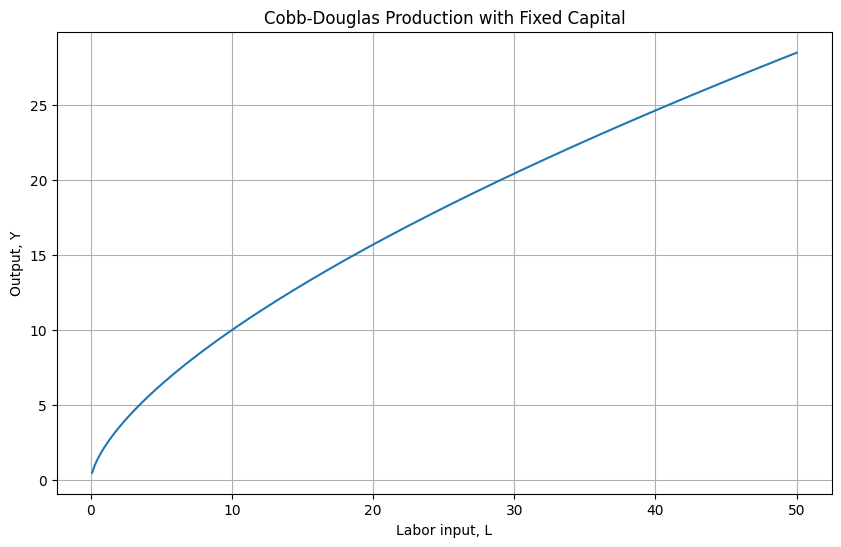

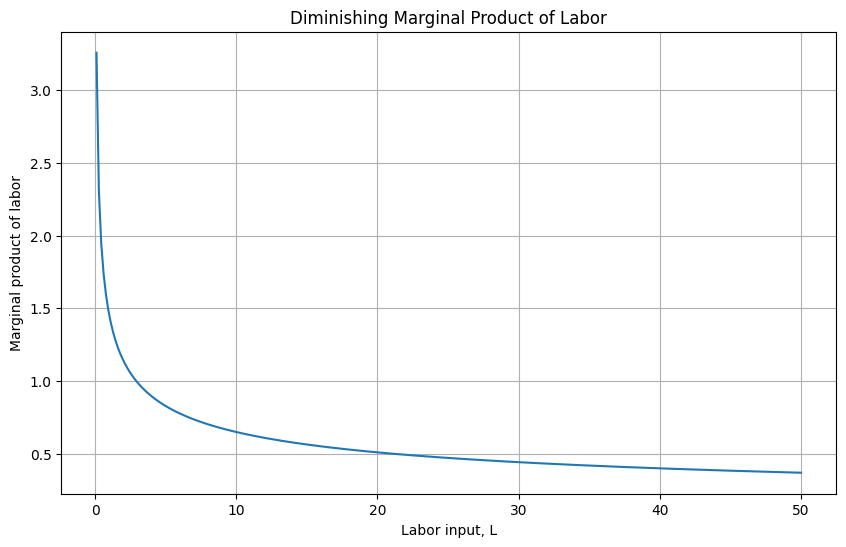

In [8]:
# Production function with fixed K

A = 1.0
Kbar = 10
alpha = 0.35
L = np.linspace(0.1, 50, 300)
Y = A * Kbar**alpha * L**(1-alpha)
MPL = (1-alpha) * A * Kbar**alpha * L**(-alpha)

plt.figure()
plt.plot(L, Y)
plt.xlabel("Labor input, L")
plt.ylabel("Output, Y")
plt.title("Cobb-Douglas Production with Fixed Capital")
plt.show()

plt.figure()
plt.plot(L, MPL)
plt.xlabel("Labor input, L")
plt.ylabel("Marginal product of labor")
plt.title("Diminishing Marginal Product of Labor")
plt.show()

## 11. Isoquants, isocost curves, and cost-minimizing tangency

An isoquant shows input combinations that produce the same output level:

$$
\bar{Y}=A K^{\alpha}L^{1-\alpha}.
$$

Solving for $K$ as a function of $L$ gives

$$
K
=
\left(
\frac{\bar{Y}}{A L^{1-\alpha}}
\right)^{1/\alpha}.
$$

An isocost line is

$$
C=wL+r_KK,
$$

so

$$
K=\frac{C}{r_K}-\frac{w}{r_K}L.
$$

Cost minimization occurs where the lowest feasible isocost line is tangent to the isoquant. The marginal rate of technical substitution is

$$
MRTS_{L,K}=\frac{MPL}{MPK}.
$$

For Cobb-Douglas production,

$$
MPL=(1-\alpha)AK^\alpha L^{-\alpha},
$$

and

$$
MPK=\alpha AK^{\alpha-1}L^{1-\alpha}.
$$

Therefore,

$$
\frac{MPL}{MPK}=\frac{1-\alpha}{\alpha}\frac{K}{L}.
$$

At the cost-minimizing tangency,

$$
\frac{MPL}{MPK}=\frac{w}{r_K}.
$$

Again, an optimality condition equates a marginal rate of substitution or transformation to a relative price.

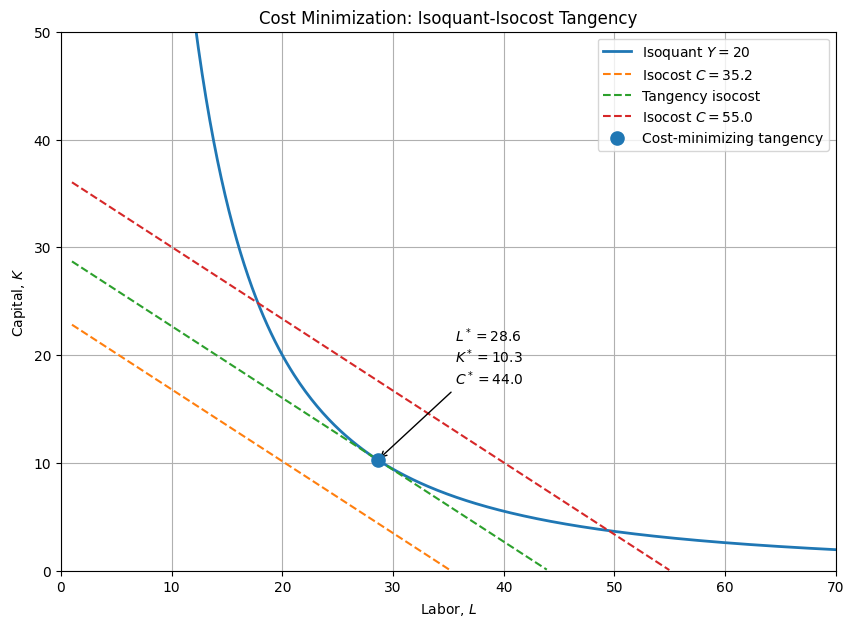

MPL/MPK at optimum: 0.667
Input price ratio w/r_K: 0.667


In [9]:
# Isoquant and isocost diagram with the cost-minimizing tangency marked

A = 1.0
alpha = 0.35
Ybar = 20.0
w = 1.0
rental_rate = 1.5

# Tangency condition: ((1-alpha)/alpha) * (K/L) = w/rental_rate
K_over_L_star = (alpha / (1 - alpha)) * (w / rental_rate)
L_star = (Ybar / (A * K_over_L_star**alpha)) ** (1.0 / (alpha + (1 - alpha)))
K_star = K_over_L_star * L_star
C_star = w * L_star + rental_rate * K_star

L_grid = np.linspace(1, 70, 400)
K_iso = (Ybar / (A * L_grid ** (1 - alpha))) ** (1 / alpha)

plt.figure(figsize=(10, 7))
plt.plot(L_grid, K_iso, label=f"Isoquant $Y={Ybar:.0f}$", linewidth=2)

for C in [0.8 * C_star, C_star, 1.25 * C_star]:
    K_isocost = C / rental_rate - (w / rental_rate) * L_grid
    K_isocost[K_isocost < 0] = np.nan
    label = "Tangency isocost" if np.isclose(C, C_star) else f"Isocost $C={C:.1f}$"
    plt.plot(L_grid, K_isocost, linestyle="--", label=label)

plt.scatter(L_star, K_star, s=90, zorder=5, label="Cost-minimizing tangency")
plt.annotate(
    f"$L^*={L_star:.1f}$\n$K^*={K_star:.1f}$\n$C^*={C_star:.1f}$",
    xy=(L_star, K_star),
    xytext=(L_star + 7, K_star + 7),
    arrowprops=dict(arrowstyle="->"),
)
plt.xlim(0, 70)
plt.ylim(0, 50)
plt.xlabel("Labor, $L$")
plt.ylabel("Capital, $K$")
plt.title("Cost Minimization: Isoquant-Isocost Tangency")
plt.legend()
plt.show()

print(f"MPL/MPK at optimum: {((1-alpha)/alpha)*(K_star/L_star):.3f}")
print(f"Input price ratio w/r_K: {w/rental_rate:.3f}")

## 12. Cost curves, profit, and the output choice

With fixed capital $\bar{K}$ and wage $w$, variable cost is

$$
VC(Y)=wL(Y).
$$

From the production function,

$$
L(Y)=
\left(
\frac{Y}{A\bar{K}^{\alpha}}
\right)^{1/(1-\alpha)}.
$$

Fixed cost is

$$
FC=r_K\bar{K}.
$$

Total cost is

$$
TC(Y)=FC+VC(Y).
$$

Average variable cost is

$$
AVC(Y)=\frac{VC(Y)}{Y},
$$

average total cost is

$$
ATC(Y)=\frac{TC(Y)}{Y},
$$

and marginal cost is

$$
MC(Y)=\frac{dTC(Y)}{dY}=\frac{dVC(Y)}{dY}.
$$

The firm chooses output where

$$
MR=MC.
$$

For a competitive firm, $MR=P$. If $P>ATC(Y^*)$ at the optimal output $Y^*$, the firm earns positive economic profit:

$$
\Pi=(P-ATC(Y^*))Y^*.
$$

The diagram below uses a short-run technology with strong diminishing marginal product of labor, so marginal cost is increasing and convex. The marginal cost curve crosses both $AVC$ and $ATC$ at their minimum points.

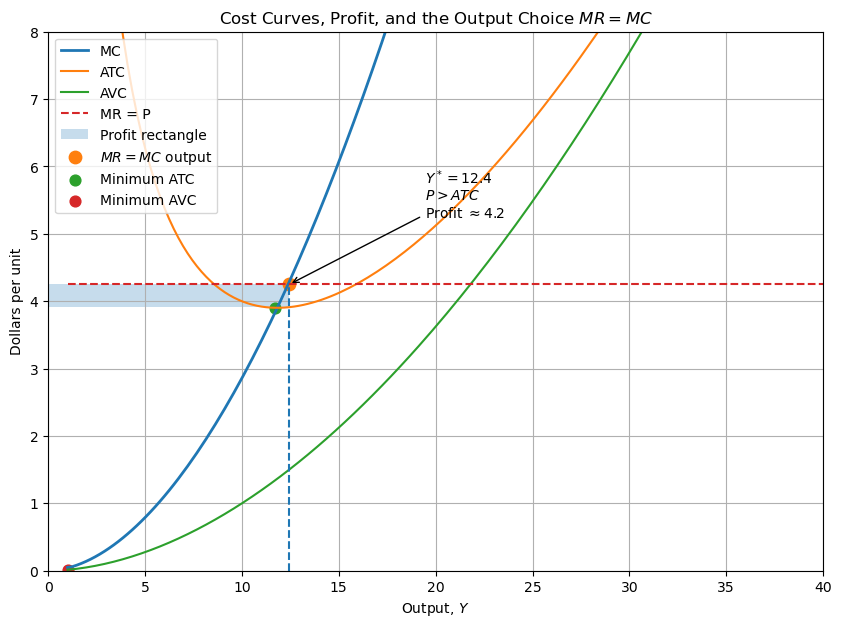

Optimal output Y*: 12.45
Price: 4.25; ATC(Y*): 3.91; AVC(Y*): 1.50; MC(Y*): 4.29
Economic profit at Y*: 4.21


In [7]:
# Cost curves with convex MC, marked output optimum, and profit rectangle

A = 1.0
Kbar = 10.0
alpha = 0.65          # Strong diminishing returns to labor -> convex MC in this short-run example
wage = 1.0
rental_rate = 3.0
FC = rental_rate * Kbar

Y_grid = np.linspace(1, 120, 500)
L_required = (Y_grid / (A * Kbar**alpha)) ** (1 / (1 - alpha))
VC = wage * L_required
TC = FC + VC
AVC = VC / Y_grid
ATC = TC / Y_grid
MC = np.gradient(TC, Y_grid)

price = 4.25
MR = np.ones_like(Y_grid) * price
q_star = Y_grid[np.argmin(np.abs(MC - price))]
atc_star = np.interp(q_star, Y_grid, ATC)
avc_star = np.interp(q_star, Y_grid, AVC)
mc_star = np.interp(q_star, Y_grid, MC)
profit = (price - atc_star) * q_star

q_atc_min = Y_grid[np.argmin(ATC)]
q_avc_min = Y_grid[np.argmin(AVC)]

plt.figure(figsize=(10, 7))
plt.plot(Y_grid, MC, label="MC", linewidth=2)
plt.plot(Y_grid, ATC, label="ATC")
plt.plot(Y_grid, AVC, label="AVC")
plt.plot(Y_grid, MR, linestyle="--", label="MR = P")

# Profit rectangle: height P - ATC(q*) and width q*
plt.fill_between([0, q_star], [atc_star, atc_star], [price, price], alpha=0.25, label="Profit rectangle")
plt.vlines(q_star, 0, price, linestyles="--")
plt.scatter([q_star], [price], s=80, label="$MR=MC$ output")
plt.scatter([q_atc_min], [ATC.min()], s=60, label="Minimum ATC")
plt.scatter([q_avc_min], [AVC.min()], s=60, label="Minimum AVC")

plt.annotate(
    f"$Y^*={q_star:.1f}$\n$P>ATC$\nProfit $\\approx {profit:.1f}$",
    xy=(q_star, price),
    xytext=(q_star + 7, price + 1.0),
    arrowprops=dict(arrowstyle="->"),
)
plt.ylim(0, 8)
plt.xlim(0, 40)
plt.xlabel("Output, $Y$")
plt.ylabel("Dollars per unit")
plt.title("Cost Curves, Profit, and the Output Choice $MR=MC$")
plt.legend(loc="upper left")
plt.show()

print(f"Optimal output Y*: {q_star:.2f}")
print(f"Price: {price:.2f}; ATC(Y*): {atc_star:.2f}; AVC(Y*): {avc_star:.2f}; MC(Y*): {mc_star:.2f}")
print(f"Economic profit at Y*: {profit:.2f}")

## 13. Production-based asset pricing

A simple production-based asset pricing model values a firm's cash flows. Suppose next period's profit is

$$
\Pi_{t+1}=P_{t+1}Y_{t+1}-w_{t+1}L_{t+1}-r_{t+1}K.
$$

The firm's equity price satisfies

$$
V_t
=
\mathbb{E}_t\left[
M_{t+1}(\Pi_{t+1}+V_{t+1})
\right].
$$

In a one-period version with no continuation value,

$$
V_t
=
\mathbb{E}_t[M_{t+1}\Pi_{t+1}].
$$

Expected returns depend on how profits covary with the SDF. If profits are high in good times, when marginal utility is low and $M$ is low, the firm's cash flows are risky and investors demand a higher expected return. If profits are stable or high in bad times, the firm provides insurance and can have a lower expected return.

## 14. Operating leverage and sensitivity to shocks

Cost structure determines profit sensitivity. A firm with high fixed costs and low variable costs has high operating leverage. Its profits are very sensitive to changes in demand because revenue changes while fixed costs do not.

A firm with lower fixed costs and higher variable costs has lower operating leverage. Its costs adjust more with output, so profits may be less sensitive to demand shocks.

Operating leverage can be summarized by the degree of operating leverage:

$$
DOL=\frac{\%\Delta EBIT}{\%\Delta Sales}.
$$

In a simple linear-cost example with price $P$, variable cost $v$, fixed cost $F$, and quantity $Q$,

$$
\Pi=(P-v)Q-F.
$$

Then

$$
DOL=\frac{(P-v)Q}{(P-v)Q-F}.
$$

When fixed costs are high, the denominator can be small, so a small demand shock can produce a large percentage change in profits. This matters for asset pricing because expected returns are tied to covariance with the SDF:

$$
\mathbb{E}[R_i]-R_f=-R_f\operatorname{Cov}(M,R_i).
$$

Cost structure affects $R_i$ by affecting the cyclicality of profits.

/tmp/ipykernel_2937/4134039521.py:25: RuntimeWarning: divide by zero encountered in divide
  ATC_curve = v + F / Q_axis


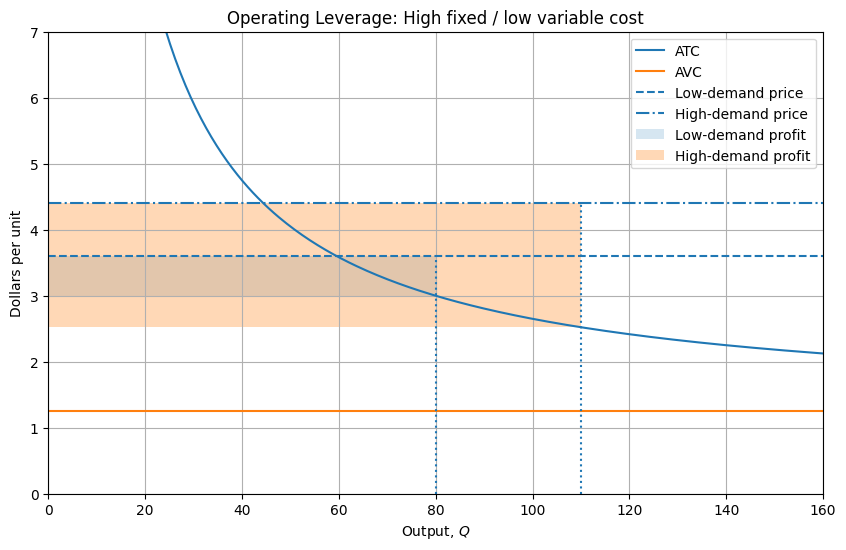

High fixed / low variable cost
  Low-demand profit:  48.00
  High-demand profit: 206.50
  Profit change / |low profit|: 330.21%



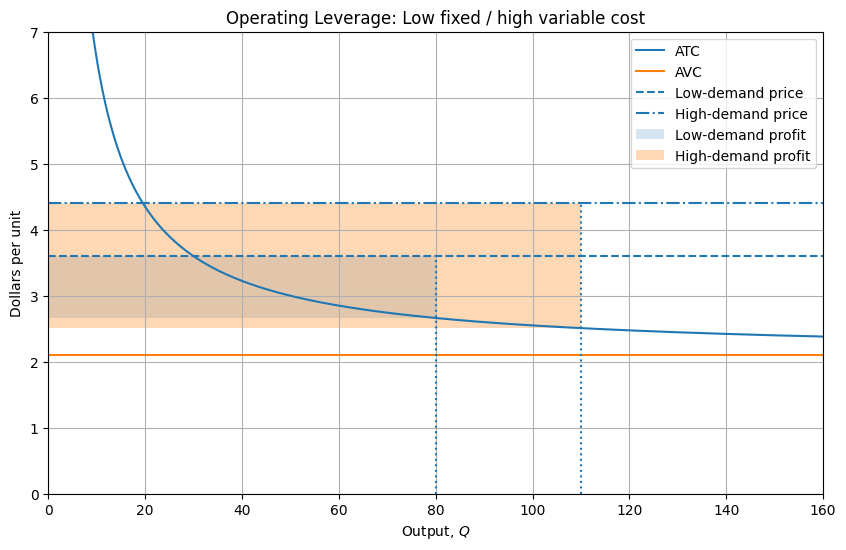

Low fixed / high variable cost
  Low-demand profit:  75.00
  High-demand profit: 208.00
  Profit change / |low profit|: 177.33%



In [11]:
# Operating leverage shown with profit rectangles under low and high demand

Q_axis = np.linspace(0, 160, 300)
P_low = 3.6
P_high = 4.4

firms = {
    "High fixed / low variable cost": {"F": 140, "v": 1.25},
    "Low fixed / high variable cost": {"F": 45, "v": 2.10},
}

for firm_name, params in firms.items():
    F = params["F"]
    v = params["v"]
    q_low = 80
    q_high = 110
    atc_low = v + F / q_low
    atc_high = v + F / q_high
    profit_low = (P_low - atc_low) * q_low
    profit_high = (P_high - atc_high) * q_high
    dol = ((P_high * q_high - P_low * q_low) / (P_low * q_low))
    profit_growth = (profit_high - profit_low) / abs(profit_low) if profit_low != 0 else np.nan

    plt.figure(figsize=(10, 6))
    ATC_curve = v + F / Q_axis
    AVC_curve = np.ones_like(Q_axis) * v
    plt.plot(Q_axis, ATC_curve, label="ATC")
    plt.plot(Q_axis, AVC_curve, label="AVC")
    plt.axhline(P_low, linestyle="--", label="Low-demand price")
    plt.axhline(P_high, linestyle="-.", label="High-demand price")

    plt.fill_between([0, q_low], [atc_low, atc_low], [P_low, P_low], alpha=0.18, label="Low-demand profit")
    plt.fill_between([0, q_high], [atc_high, atc_high], [P_high, P_high], alpha=0.30, label="High-demand profit")
    plt.vlines([q_low, q_high], 0, [P_low, P_high], linestyles=":")

    plt.ylim(0, 7)
    plt.xlim(0, 160)
    plt.xlabel("Output, $Q$")
    plt.ylabel("Dollars per unit")
    plt.title(f"Operating Leverage: {firm_name}")
    plt.legend()
    plt.show()

    print(f"{firm_name}")
    print(f"  Low-demand profit:  {profit_low:,.2f}")
    print(f"  High-demand profit: {profit_high:,.2f}")
    print(f"  Profit change / |low profit|: {profit_growth:,.2%}\n")

In [12]:
# Simulate firms with different cost structures and price their profits with an SDF

np.random.seed(202)
n = 50000

# Aggregate consumption growth and SDF
g, m = simulate_sdf(beta=0.99, gamma=5, mu_g=0.018, sigma_g=0.035, n=n)
state = (g - np.mean(g)) / np.std(g)

# Demand-driven output and price
Q = 100 + 12 * state + np.random.normal(0, 4, n)
P = 2.0 + 0.10 * state + np.random.normal(0, 0.03, n)

# Firm A: high fixed cost, low variable cost
FC_A = 120
v_A = 0.55
profit_A = P * Q - FC_A - v_A * Q

# Firm B: low fixed cost, high variable cost
FC_B = 40
v_B = 1.25
profit_B = P * Q - FC_B - v_B * Q

# Shift profits if needed to keep payoffs mostly positive for return illustration
payoff_A = profit_A - np.percentile(profit_A, 1) + 5
payoff_B = profit_B - np.percentile(profit_B, 1) + 5

price_A = np.mean(m * payoff_A)
price_B = np.mean(m * payoff_B)
ret_A = payoff_A / price_A
ret_B = payoff_B / price_B
rf = 1 / np.mean(m)

prod_table = pd.DataFrame({
    "Firm": ["High fixed cost / low variable cost", "Low fixed cost / high variable cost"],
    "Price": [price_A, price_B],
    "Expected Return": [np.mean(ret_A)-1, np.mean(ret_B)-1],
    "Std. Dev. Return": [np.std(ret_A), np.std(ret_B)],
    "Cov(Return, SDF)": [np.cov(ret_A, m)[0,1], np.cov(ret_B, m)[0,1]],
    "Profit cyclicality Corr(Profit, Consumption Growth)": [
        np.corrcoef(profit_A, g)[0,1],
        np.corrcoef(profit_B, g)[0,1],
    ],
})
prod_table

,Firm,Price,Expected Return,Std. Dev. Return,"Cov(Return, SDF)","Profit cyclicality Corr(Profit, Consumption Growth)"
0,High fixed cost / low variable cost,53.8183,0.1775,0.5272,-0.0813,0.9711
1,Low fixed cost / high variable cost,37.0936,0.1779,0.5309,-0.0816,0.9723


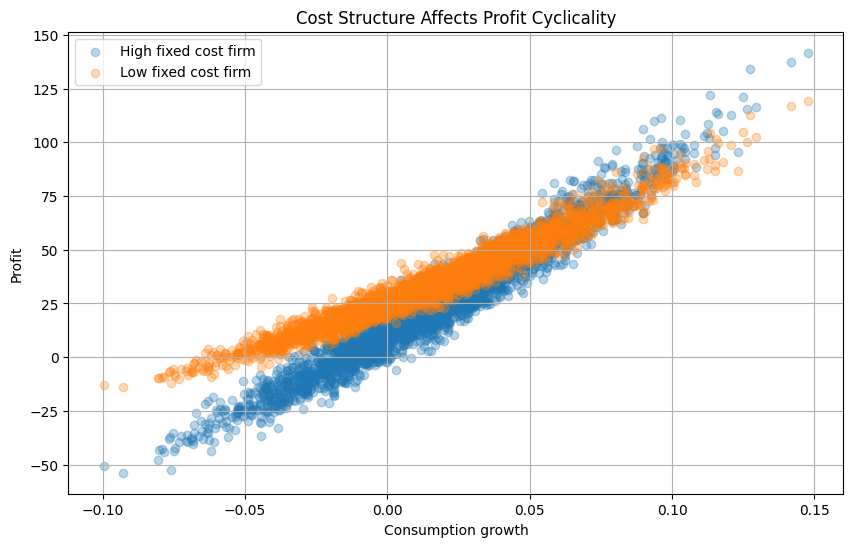

In [13]:
plt.figure()
plt.scatter(g[:3000]-1, profit_A[:3000], alpha=0.3, label="High fixed cost firm")
plt.scatter(g[:3000]-1, profit_B[:3000], alpha=0.3, label="Low fixed cost firm")
plt.xlabel("Consumption growth")
plt.ylabel("Profit")
plt.title("Cost Structure Affects Profit Cyclicality")
plt.legend()
plt.show()

## 15. Connecting price theory and asset pricing

Price theory explains how firms produce, choose inputs, face cost curves, and respond to supply and demand shocks. Asset pricing explains how investors value the resulting cash flows.

The bridge is the stochastic discount factor:

$$
V_t = \mathbb{E}_t[M_{t+1}X_{t+1}].
$$

For a firm's equity, $X_{t+1}$ is tied to profits, dividends, or free cash flows. Those cash flows are shaped by:

1. demand elasticity,
2. supply shocks,
3. production technology,
4. input prices,
5. fixed versus variable costs,
6. operating leverage,
7. financial leverage,
8. covariance with aggregate marginal utility.

Thus, microeconomic cost and demand analysis helps explain why some assets are riskier than others.

## 16. Summary

Consumption-based asset pricing begins with intertemporal choice. The SDF is the marginal rate of substitution between consumption today and consumption tomorrow. The tangency point in the two-period consumption diagram is therefore not merely a picture; it is the economic origin of the pricing kernel. At the optimum,

$$
\frac{u'(C_t)}{\beta u'(C_{t+1})}=1+r.
$$

Assets are valuable if they pay off when marginal utility is high. The Lucas tree model applies this logic to a representative-agent endowment economy.

The Hansen-Jagannathan bound shows that any valid SDF must be volatile enough to explain observed Sharpe ratios. The equity premium puzzle and risk-free rate puzzle show that simple consumption-based models struggle to match observed asset returns with plausible parameters.

Production-based asset pricing adds firms, production technologies, input choices, and cost structures. The isoquant-isocost tangency condition,

$$
\frac{MPL}{MPK}=\frac{w}{r_K},
$$

is the production-side analogue of the household's marginal-utility tangency condition. A firm's output choice then follows

$$
MR=MC.
$$

If $P>ATC$ at that output, the firm generates profits for investors to value. A firm's value is the discounted value of future profits or cash flows:

$$
V_t=\mathbb{E}_t[M_{t+1}X_{t+1}].
$$

Cost curvature, fixed costs, variable costs, operating leverage, demand cyclicality, and input-price exposure all affect the covariance of cash flows with the SDF. If profits covary negatively with the SDF, the firm is risky and must offer higher expected returns. If profits covary positively with the SDF, the firm provides insurance and can command a higher price and lower expected return.